# Day 4: Linear Regression Lifecycle

Linear Regression is the fundamental 'Hello World' of ML modeling. We will explore Simple, Multiple, and Polynomial Regression today.

## 1. Mathematical Intuition
$y = \beta_0 + \beta_1x_1 + \dots + \beta_nx_n + \epsilon$
Goal: Find the weights $\beta$ that minimize the RSS (Residual Sum of Squares).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures

# Load Housing dataset (California)
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Train/Test Split and Simple Linear Regression
Using Median Income (MedInc) to predict House Value.

In [2]:
X = df[['MedInc']]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"Intercept: {lr.intercept_:.4f}")
print(f"Coefficient: {lr.coef_[0]:.4f}")

Intercept: 0.4446
Coefficient: 0.4193


## 3. Evaluation Metrics
How good is our model? Let's analyze metrics like $R^2$ and RMSE.

R2 Score: 0.4589
RMSE: 0.8421


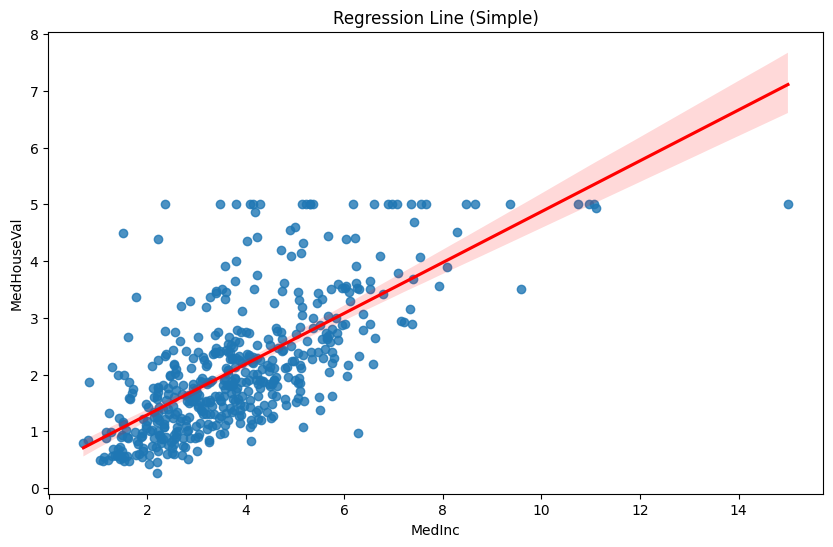

In [3]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# Visualize regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='MedInc', y='MedHouseVal', data=df.sample(500), line_kws={"color": "red"})
plt.title("Regression Line (Simple)")
plt.show()

## 4. Multiple and Polynomial Regression
Linearity is an assumption. Let's see how adding complexity helps or hurts model performance.

In [4]:
X_multi = df.drop('MedHouseVal', axis=1)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train_m)
y_pred_m = lr_multi.predict(X_test_m)
print(f"Multiple Regression R2: {r2_score(y_test_m, y_pred_m):.4f}")

Multiple Regression R2: 0.5758


## Hands-on Exercise
Compare Multiple Linear Regression with Polynomial Regression (degree=2). Plot the residual distribution for both to see improvement.

## Mini Project
Build a 'Rent Predictor' using basic housing features and compare its accuracy with $R^2$ and MAE.